# Figures
This notebook is for generating figures in the main text manuscript as well as the supplementary information.

In [1]:
import os
from glob import glob

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import numpy as np
import pandas as pd
import rioxarray as rxr
import seaborn as sns
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from ipywidgets import interact
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap
from matplotlib_map_utils.core.scale_bar import ScaleBar, scale_bar
from rasterio.enums import Resampling
from rioxarray.merge import merge_arrays
from scipy.stats import pearsonr, spearmanr

from config import (
    GADM_FILE,
    INTERIM_DIR,
    MODEL_NAMES,
    MODEL_PAIRS,
    PROCESSED_DIR,
    REPORTS_DIR,
)
from modules.sampling import spatial_alignment
from modules.utils import countries, raster_to_hexgrid, read_boundary

### Figure 1: Spatial agreement of model predictions

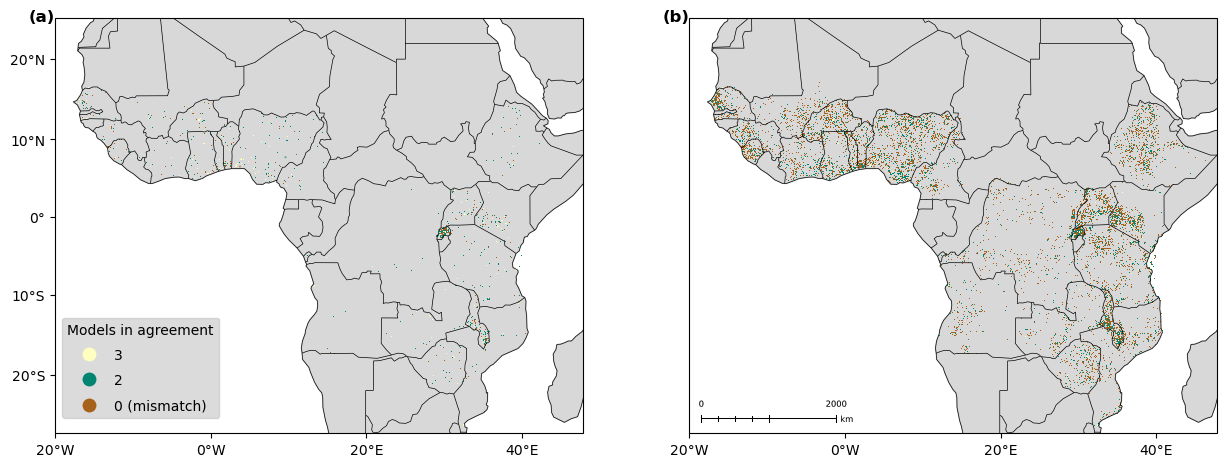

In [2]:
# using projected crs
mercator = ccrs.Mercator()

# template layer for plotting
template = gpd.read_file(GADM_FILE, layer="SA_template")
template = template[template["Value"].isin([0, 2, 3])]
template = template.to_crs(mercator.proj4_init)

# create a colormap for the agreement values
qmap = ListedColormap(["#a6611a", "#000000", "#018571", "#ffffbf"])

fig, axs = plt.subplots(
    1, 2, figsize=(15, 8), subplot_kw={"projection": mercator}, sharey=True
)

for i, mp in enumerate(["unanimous", "majority"]):
    # read spatial agreement raster for combined countries
    rasters = rxr.open_rasterio(
        os.path.join(
            PROCESSED_DIR,
            f"pixel-wise/quintiles/unpooled/{mp}",
            f"spatial_agreement_map_{mp[0]}.tif",
        )
    ).squeeze()
    rasters = rasters.rio.reproject(mercator.proj4_init)
    # plot the data
    rasters.plot.imshow(ax=axs[i], cmap=qmap, add_colorbar=False)
    # add country boundaries and other features
    axs[i].coastlines(linewidth=0.5)
    axs[i].add_feature(cfeature.BORDERS, linewidth=0.5)
    axs[i].add_feature(cfeature.LAND, color="grey", alpha=0.3)
    # axs.add_feature(cfeature.OCEAN, color=cfeature.COLORS['water'], alpha=0.2)
    template.plot(
        ax=axs[i],
        column="Value",
        markersize=0.1,
        categorical=True,
        cmap=qmap,
        legend=True if i == 0 else False,
        legend_kwds={
            "loc": "lower left",
            "bbox_to_anchor": (0, 0.02),
            "labelspacing": 0.8,
            "frameon": True,
            "reverse": True,
            "title": "Models in agreement",
            "labels": ["0 (mismatch)", "2", "3"],
            "facecolor": "lightgrey",
        },
    )
    # add x tickmarks
    axs[i].set_xticks([-20, 0, 20, 40], crs=ccrs.PlateCarree())
    axs[i].xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))

    axs[i].set_title("")
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")

# add scale bar
ScaleBar.set_size("small")
scale_bar(
    axs[1],
    location="lower left",
    style="ticks",
    bar={
        "projection": template.crs,
        "max": 2000,
        "tick_loc": "middle",
        "major_div": 2,
        "minor_div": 4,
        "minor_type": "first",
    },
)
# add y tickmarks
axs[0].set_yticks([-20, -10, 0, 10, 20], crs=ccrs.PlateCarree())
axs[0].yaxis.set_major_formatter(LatitudeFormatter())

for i, alph in enumerate(["a", "b"]):
    axs[i].text(
        -0.05,
        1.02,
        f"({alph})",
        transform=axs[i].transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )

# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "fig1.png"), dpi=300, bbox_inches="tight"
# )

### Figure 2: Majority vote ensemble poverty map

Text(0, 0.5, '')

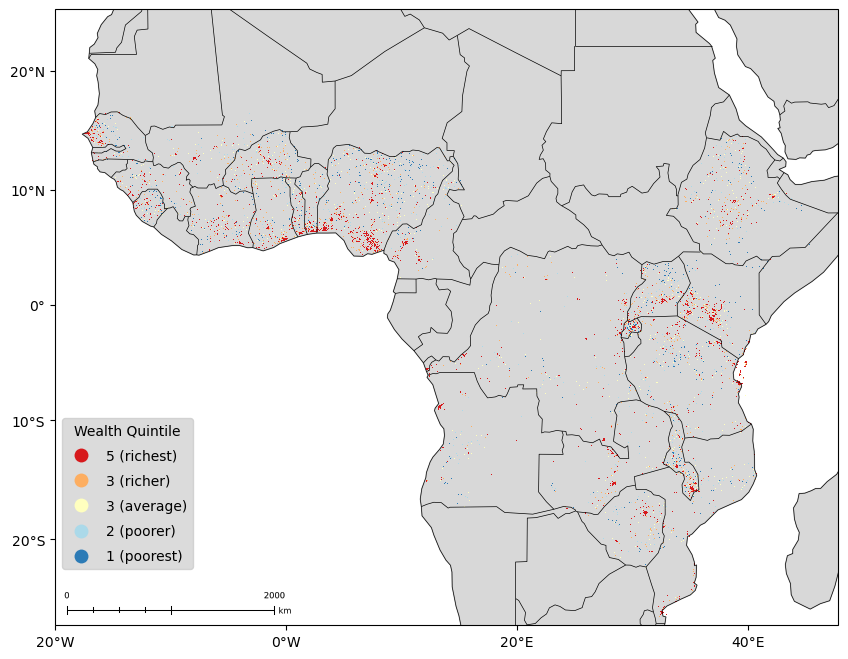

In [11]:
# read majority vote ensemble poverty map
rasters = rxr.open_rasterio(
    os.path.join(
        PROCESSED_DIR,
        "pixel-wise/quintiles/unpooled/majority",
        "majority_ensemble_map.tif",
    )
).squeeze()
# template layer for plotting
template = gpd.read_file(GADM_FILE, layer="quintile_template")
# template = gpd.read_file(r"../data/external/quintile_template.geojson")
# using projected crs
mercator = ccrs.Mercator()
template = template.to_crs(mercator.proj4_init)
rasters = rasters.rio.reproject(mercator.proj4_init)
# create a colormap for the wealth classes
qmap = ListedColormap(
    ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"]
)  # poorest, poorer, average, richer, richest

fig, axs = plt.subplots(1, 1, figsize=(15, 8), subplot_kw={"projection": mercator})
# plot the data
rasters.plot.imshow(ax=axs, cmap=qmap, add_colorbar=False)
# add country boundaries and other features
axs.coastlines(linewidth=0.5)
axs.add_feature(cfeature.BORDERS, linewidth=0.5)
axs.add_feature(cfeature.LAND, color="grey", alpha=0.3)

template.plot(
    ax=axs,
    column="Value",
    markersize=0.01,
    categorical=True,
    cmap=qmap,
    legend=True,
    legend_kwds={
        "loc": "lower left",
        "bbox_to_anchor": (0, 0.08),
        "labelspacing": 0.8,
        "frameon": True,
        "reverse": True,
        "title": "Wealth Quintile",
        "labels": [
            "1 (poorest)",
            "2 (poorer)",
            "3 (average)",
            "3 (richer)",
            "5 (richest)",
        ],
        "facecolor": "lightgrey",
    },
)

# add scale bar
ScaleBar.set_size("small")
scale_bar(
    axs,
    location="lower left",
    style="ticks",
    bar={
        "projection": template.crs,
        "max": 2000,
        "tick_loc": "middle",
        "major_div": 2,
        "minor_div": 4,
        "minor_type": "first",
    },
)
# add tickmarks
axs.set_xticks([-20, 0, 20, 40], crs=ccrs.PlateCarree())
axs.set_yticks([-20, -10, 0, 10, 20], crs=ccrs.PlateCarree())
axs.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
axs.yaxis.set_major_formatter(LatitudeFormatter())

axs.set_title("")
axs.set_xlabel("")
axs.set_ylabel("")

# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "fig2.png"), dpi=300, bbox_inches="tight"
# )

### Figure 3: High and low pairwise agreement

In [2]:
# countries of interest
selected_countries = ["Mali", "Mozambique"]
# pairwise agreement scores
proportions = pd.read_csv(
    os.path.join(
        PROCESSED_DIR, "pixel-wise/terciles/unpooled", "Pairwise_wealth_classes.csv"
    )
)
# tickmarks for plotting
xticks_list = [
    [-12, -8, -4, 0, 4],
    [30, 34, 38, 42],
]
yticks_list = [[12, 16, 20, 24], [-25, -20, -15, -10]]
# using projected crs
mercator = ccrs.Mercator()
# read pairwise comparison maps for selected countries
data_dict = dict()
for country, xticks, yticks in zip(selected_countries, xticks_list, yticks_list):
    data_dict[country] = dict()
    # filter agreement metrics for the country
    metrics = proportions[proportions["Country"] == country]

    for pair, cat in zip(["Lee_McCallum", "Chi_Yeh"], ["best", "worst"]):
        data_dict[country][cat] = dict()
        # read the raster data and boundary for each country
        data_dict[country][cat]["data"] = (
            rxr.open_rasterio(
                os.path.join(
                    INTERIM_DIR,
                    "raster_stacks",
                    "pairwise_agreement",
                    f"{pair}_{country}_models.tif",
                ),
                masked=True,
            )
            .squeeze()
            .rio.reproject(mercator.proj4_init)
        )
        # get agreement score, correlation and number of pixels
        data_dict[country][cat]["model_pair"] = pair

        for x in ["agree", "correlation", "N"]:
            data_dict[country][cat][f"{x}"] = metrics.loc[
                metrics["Models"] == pair, f"{x}"
            ].values[0]
    # read and reproject country boundary
    data_dict[country]["boundary"] = read_boundary(country).to_crs(mercator.proj4_init)
    # add tickmarks for each country
    data_dict[country]["xticks"] = xticks
    data_dict[country]["yticks"] = yticks

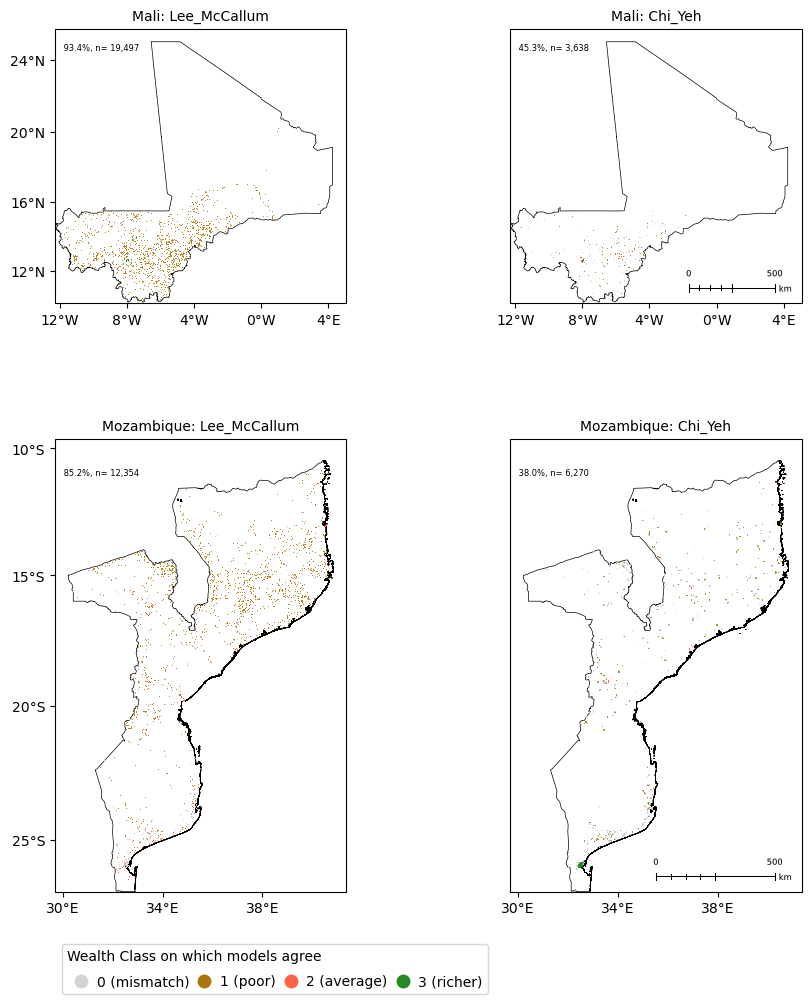

In [10]:
# create a colormap for the wealth terciles
qmap = ListedColormap(
    ["lightgrey", "#aa750adc", "#ff6347", "#228B22"]  # mismatch, poor, average, richer
)

fig = plt.figure(figsize=(8, 10), constrained_layout=True)
gs = fig.add_gridspec(6, 2)
ax1 = fig.add_subplot(gs[:2, 0], projection=mercator)
ax2 = fig.add_subplot(gs[:2, 1], projection=mercator, sharey=ax1)
ax3 = fig.add_subplot(gs[2:, 0], projection=mercator)
ax4 = fig.add_subplot(gs[2:, 1], projection=mercator, sharey=ax3)
axs = np.array([[ax1, ax2], [ax3, ax4]])

# plot maps and boundaries
for i, country in enumerate(selected_countries):
    for j, cat in enumerate(["best", "worst"]):
        data_dict[country]["boundary"].plot(
            ax=axs[i, j], facecolor="none", edgecolor="black", linewidth=0.5
        )
        data_dict[country][cat]["data"].plot(
            ax=axs[i, j], cmap=qmap, add_colorbar=False
        )
        # add annotations
        axs[i, j].text(
            0.02,
            0.92,
            f"{data_dict[country][cat]['agree']: .1f}%, n={data_dict[country][cat]['N']: ,}",
            fontsize=6,
            ha="left",
            transform=axs[i, j].transAxes,
        )
        axs[i, j].set_title(
            f"{country}: {data_dict[country][cat]['model_pair']}", fontsize=10
        )

        # add tickmarks
        axs[i, j].set_xticks(data_dict[country]["xticks"], crs=ccrs.PlateCarree())
        axs[i, j].set_yticks(data_dict[country]["yticks"], crs=ccrs.PlateCarree())
        axs[i, j].xaxis.set_major_formatter(
            LongitudeFormatter(zero_direction_label=True)
        )
        axs[i, j].yaxis.set_major_formatter(LatitudeFormatter())
        axs[i, j].set_xlabel("")
        axs[i, j].set_ylabel("")

# add scale bar
ScaleBar.set_size("small")

# Hide y-tick labels on right-hand subplots
for row in axs:
    row[1].yaxis.set_visible(False)
    # add scale bar
    scale_bar(
        row[1],
        location="lower right",
        style="ticks",
        bar={
            "projection": mercator.proj4_init,
            "max": 500,
            "tick_loc": "middle",
            "major_div": 2,
            "minor_div": 4,
            "minor_type": "first",
        },
    )

# read template layer for plotting
template = gpd.read_file(PROCESSED_DIR / "ensemble_terciles.geojson")
template = template[template["Country"] == "moz"]
template = template.to_crs(mercator.proj4_init)
# plot the template layer with wealth terciles
template.plot(
    ax=axs[1, 0],
    column="Value",
    markersize=0.01,
    categorical=True,
    cmap=qmap,
    legend=True,
    categories=[0, 1, 2, 3],
    legend_kwds={
        "ncols": 4,
        "loc": "upper left",
        "labelspacing": 0.8,
        "frameon": True,
        "reverse": False,
        "alignment": "left",
        "title": "Wealth Class on which models agree",
        "bbox_to_anchor": (0, -0.1),
        "columnspacing": 0.1,
        "handletextpad": 0.1,
        "labels": ["0 (mismatch)", "1 (poor)", "2 (average)", "3 (richer)"],
    },
)

template.plot(
    ax=axs[1, 1],
    column="Value",
    markersize=0.01,
    categorical=True,
    cmap=qmap,
    legend=False,
)

plt.savefig(
    os.path.join(REPORTS_DIR, "figures", "fig3.png"), dpi=300, bbox_inches="tight"
)

### Figure 4: Model performance boxplots

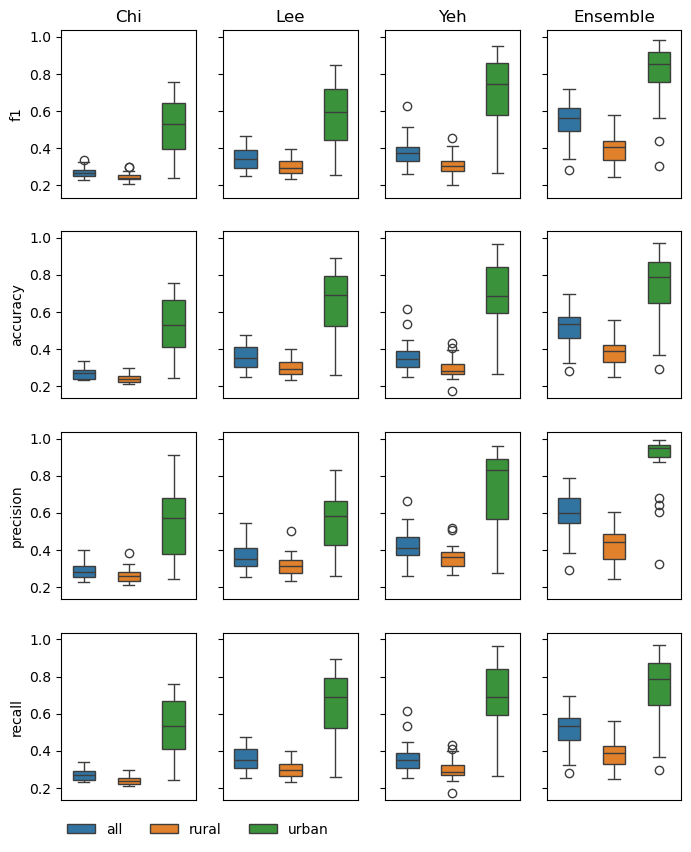

In [28]:
# read performance metrics for individual countries
df = pd.read_csv(
    os.path.join(
        PROCESSED_DIR,
        "pixel-wise/quintiles/unpooled",
        "DHS_metrics.csv",
    )
)
df = df.sort_values(by=["Cluster"])

fig, axs = plt.subplots(
    4, len(MODEL_NAMES) + 1, sharey=True, sharex=True, figsize=(8, 10)
)
for idy, metric in enumerate(["f1", "accuracy", "precision", "recall"]):
    for idx, model in enumerate(MODEL_NAMES + ["Ensemble"]):
        if metric == "correlation" and model == "Ensemble":
            continue
        sns.boxplot(
            df[df["metric"] == metric],
            x="Cluster",
            y=model,
            hue="Cluster",
            width=0.5,
            legend=True,
            ax=axs[idy, idx],
        )
        axs[0, idx].set_title(f"{model}")
    axs[idy, 0].set_ylabel(metric)

# axs[0, -1].axis("off")
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.legend().set_visible(False)
axs[3, 0].legend(loc=(0, -0.25), ncol=3, frameon=False).set_visible(True)

# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "fig4.png"), dpi=300, bbox_inches="tight"
# )

### SI Figure 1: Spatial agreement by settlement type

/tmp/ipykernel_2865099/2678887053.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pivot.index, rotation=90)
/tmp/ipykernel_2865099/2678887053.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pivot.index, rotation=90)
/tmp/ipykernel_2865099/2678887053.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pivot.index, rotation=90)
/tmp/ipykernel_2865099/2678887053.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pivot.index, rotation=90)
/tmp/ipykernel_2865099/2678887053.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_

/tmp/ipykernel_2865099/2678887053.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pivot.index, rotation=90)


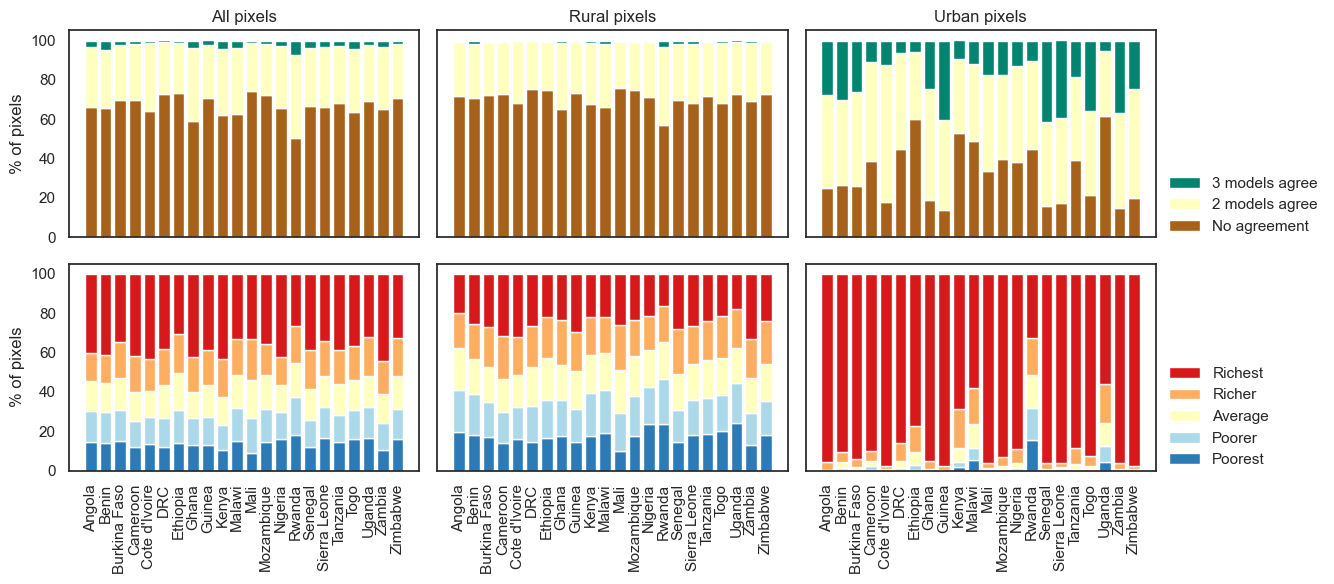

In [30]:
# Seaborn theme with plain (no gridlines)
sns.set_theme(style="white")

# Create subplots — one per cluster
fig, axs = plt.subplots(2, 3, figsize=(15, 6), sharey=True, sharex=True)

data = dict()
# prepare data for plotting barplots
for df in ["agreement", "majority"]:
    data[df] = dict()
    # Read pixel-wise statistics
    stats = pd.read_csv(
        os.path.join(
            PROCESSED_DIR,
            "pixel-wise/quintiles/unpooled/majority",
            f"{df}_pixel_stats.csv",
        )
    ).sort_values(by=["Cluster"])

    stats["Country"] = stats["Country"].replace(
        {"Democratic Republic of the Congo": "DRC"}
    )
    stats = stats[stats["Country"] != "Overall"]
    data[df]["categories"] = stats.columns[2:]
    data[df]["clusters"] = stats["Cluster"].unique()

    # Reshape for plotting
    data[df]["table"] = stats.melt(
        id_vars=["Country", "Cluster"],
        value_vars=data[df]["categories"],
        var_name="Category",
        value_name="Value",
    )
    # color mapping for categories
    data[df]["color_map"] = (
        ListedColormap(
            ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"]
        )  # poorest, poorer, average, richer, richest
        if df == "majority"
        else ListedColormap(["#a6611a", "#ffffbf", "#018571"])  # agreement
    )
# plot barplots
for i, df in enumerate(["agreement", "majority"]):
    for j, cl in enumerate(data[df]["clusters"]):
        ax = axs[i, j]
        subset = data[df]["table"][data[df]["table"]["Cluster"] == cl]
        pivot = subset.pivot(index="Country", columns="Category", values="Value")

        # Stack categories
        bottom = None
        for k, cat in enumerate(data[df]["categories"]):
            ax.bar(
                pivot.index,
                pivot[cat],
                bottom=bottom,
                color=data[df]["color_map"].colors[k],
                label=cat if j == 2 else "",
            )
            bottom = pivot[cat] if bottom is None else bottom + pivot[cat]

        ax.set_xlabel("")
        if j == 0:
            ax.set_ylabel("% of pixels")
        if i == 0:
            ax.set_title(f"{cl.capitalize()} pixels")
        ax.set_xticklabels(pivot.index, rotation=90)

# Shared legends
for i in range(2):
    handles, labels = axs[i, -1].get_legend_handles_labels()
    axs[i, -1].legend(
        handles[::-1],  # reverse the order of handles and labels
        labels[::-1],
        # title="Category",
        loc="lower left",
        bbox_to_anchor=(1, -0.05),
        frameon=False,
    )

plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "SI_fig1.png"), dpi=300, bbox_inches="tight"
# )

### SI Figure 2: Unanimous vote ensemble poverty map

In [31]:
raster = rxr.open_rasterio(
    os.path.join(
        PROCESSED_DIR,
        "pixel-wise/quintiles/unpooled/unanimous",
        "unanimous_ensemble_map.tif",
    )
).squeeze()
# using projected crs
mercator = ccrs.Mercator()
raster = raster.rio.reproject(mercator.proj4_init)

# create hexgrid of the ensemble
hexgrid = raster_to_hexgrid(raster, agg_method="antimode", factor=400)

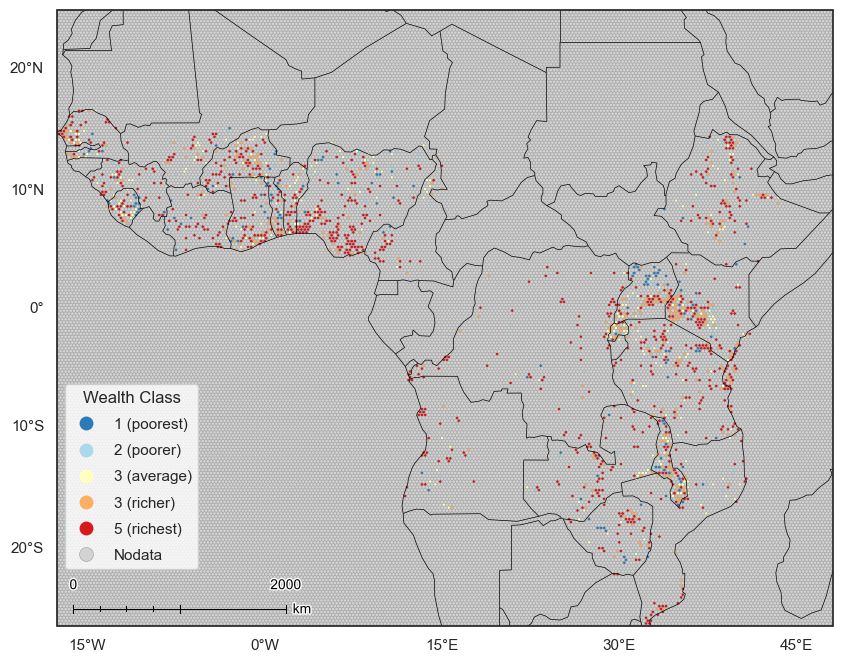

In [33]:
# create a colormap for the wealth terciles
qmap = ListedColormap(
    ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"]
)  # poorest, poorer, average, richer, richest

fig, axs = plt.subplots(1, 1, figsize=(15, 8), subplot_kw={"projection": mercator})

# define plot extent
axs.set_xlim([-1.95e6, 5.35e6])
axs.set_ylim([-3.0e6, 2.8e6])

# plot the hexagonal choropleth
hexgrid.plot(
    column="Value",
    ax=axs,
    cmap=qmap,
    edgecolor="darkgrey",
    linewidth=0.5,
    legend=True,
    categorical=True,
    legend_kwds={
        "loc": "lower left",
        "bbox_to_anchor": (0, 0.08),
        "labelspacing": 0.8,
        "frameon": True,
        "reverse": False,
        "title": "Wealth Class",
        "labels": [
            "1 (poorest)",
            "2 (poorer)",
            "3 (average)",
            "3 (richer)",
            "5 (richest)",
            "Nodata",
        ],
    },
    missing_kwds={"color": "lightgrey", "label": "Nodata"},
)
# add country boundaries and other features
axs.coastlines(linewidth=0.5)
axs.add_feature(cfeature.BORDERS, linewidth=0.5)
# add scale bar
ScaleBar.set_size("small")
scale_bar(
    axs,
    location="lower left",
    style="ticks",
    bar={
        "projection": hexgrid.crs,
        "max": 2000,
        "tick_loc": "middle",
        "major_div": 2,
        "minor_div": 4,
        "minor_type": "first",
    },
    labels={
        "stroke_width": 2,
        "fontsize": 10,
    },
    units={
        "stroke_width": 2,
        "fontsize": 10,
    },
)
# add tickmarks
axs.set_xticks([-15, 0, 15, 30, 45], crs=ccrs.PlateCarree())
axs.set_yticks([-20, -10, 0, 10, 20], crs=ccrs.PlateCarree())
axs.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
axs.yaxis.set_major_formatter(LatitudeFormatter())

# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "SI_fig2.png"), dpi=300, bbox_inches="tight"
# )


### SI Figure 3: Pairwise agreement heatmap

In [34]:
# read pairwise agreement proportions
proportions = pd.read_csv(
    os.path.join(
        PROCESSED_DIR,
        "pixel-wise/quintiles/unpooled",
        "Pairwise_agreement_pixel_stats.csv",
    )
)
proportions["Country"] = proportions["Country"].replace(
    {"Democratic Republic of the Congo": "DRC"}
)
proportions = (proportions.set_index("Country").map(lambda x: x / 100))[MODEL_PAIRS]
# plot the data
fig, axs = plt.subplots(1, 1, figsize=(8, 8))
sns.heatmap(
    proportions,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Spatial Agreement"},
)
axs.set_ylabel("")
# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "SI_fig3.png"), dpi=300, bbox_inches="tight"
# )

TypeError: unsupported operand type(s) for /: 'str' and 'int'

### SI Figure 4: Model correlation

In [2]:
# dictionary to hold aligned rasters for each country
rasters = dict()

for country in countries.keys():
    # align rasters to each other and resample to the same resolution
    rasters[country] = spatial_alignment(country)
# merge all countries into single raster
merged_raster = merge_arrays([rasters[country] for country in countries.keys()])

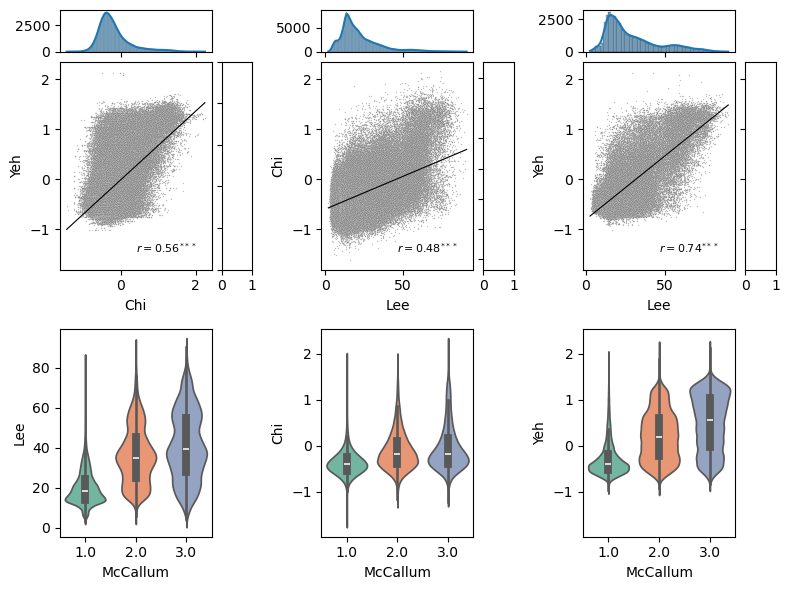

In [20]:
fig, axs = plt.subplots(2, 3, figsize=(8, 6), tight_layout=True)
for i in range(1, 3):
    axs[0, i].sharey(axs[0, 0])
    axs[1, i].sharey(axs[1, 1])

for ax, pair in zip(axs.flatten(), MODEL_PAIRS):
    x, y = pair.split("_")
    ds = merged_raster.sel(model=[x, y]).to_dataset(dim="model")
    df = (ds.to_dataframe().dropna().reset_index(drop=True))[[x, y]]
    # # set axis limits to avoid issues with marginal plots
    # ax.set_xlim(df[x].min(), df[x].max())
    # ax.set_ylim(df[y].min(), df[y].max())

    # attach marginal axes
    divider = make_axes_locatable(ax)
    ax_histx = divider.append_axes("top", size="20%", pad=0.1, sharex=ax)
    ax_histy = divider.append_axes("right", size="20%", pad=0.1)  # , sharey=ax)
    ax_histy.set_ylim(ax.get_ylim())

    # turn off labels for marginals
    plt.setp(ax_histx.get_xticklabels(), visible=False)
    plt.setp(ax_histy.get_yticklabels(), visible=False)

    if pair in MODEL_PAIRS[:3]:
        # calculate pearson's correlation
        coeff, p = pearsonr(df[x], df[y])
        # determine significance level
        stars = "***" if p < 1e-5 else "*"
        # regression line
        sns.regplot(
            df,
            x=x,
            y=y,
            ax=ax,
            scatter=False,
            line_kws={"color": "black", "linewidth": 0.8},
        )
        # scatter points
        sns.scatterplot(
            df,
            x=x,
            y=y,
            ax=ax,
            s=1,
            c="grey",
            alpha=0.5,
        )
        # marginal distributions
        sns.histplot(df[x], ax=ax_histx, kde=True)
        # sns.histplot(df[y], ax=ax_histy, kde=True, orientation="horizontal")
        ax_histx.set_ylabel("")
        # annotate correlation coefficient
        ax.text(
            0.5,
            0.08,
            f"$r = {coeff: .2f}^{{{stars}}}$",
            fontsize=8,
            transform=ax.transAxes,
        )
    else:
        sns.violinplot(
            x=y, y=x, data=df, palette="Set2", inner="box", hue=y, ax=ax, legend=False
        )
        # hide marginal axes from violin plots
        ax_histx.set_visible(False)
        ax_histy.set_visible(False)

axs[0, 0].set_yticks([-1, 0, 1, 2])
# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "SI_fig4.png"), dpi=300, bbox_inches="tight"
# )

In [ ]:
# # read stats
# stats = pd.read_csv(
#     os.path.join(
#         PROCESSED_DIR,
#         "pixel-wise/terciles/unpooled",
#         "Pairwise_wealth_classes.csv",
#     )
# )

# # calculate pearson's correlation
# coeff, p = pearsonr(stats["agree"], stats["correlation"])
# # determine significance level
# stars = "***" if p < 1e-5 else "*"

# fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# sns.regplot(
#     stats,
#     x="correlation",
#     y="agree",
#     ax=axs,
#     scatter=False,
#     line_kws={"color": "black"},
# )
# sns.scatterplot(
#     stats,
#     x="correlation",
#     y="agree",
#     ax=axs,
#     hue="Models",
# )
# axs.set_xlabel("Pearson's rho correlation coefficient")
# axs.set_ylabel("Spatial Agreement score (%)")
# plt.legend(title="Model pair", frameon=True)
# axs.text(
#     0.5,
#     0.02,
#     rf"$r = {coeff: .2f}^{{{stars}}}$",
#     fontsize=10,
#     ha="left",
#     transform=axs.transAxes,
# )
#
# # model correlation vs agreement score
# plt.savefig(
#     os.path.join(REPORTS_DIR, "figures", "SI_fig4.png"), dpi=300, bbox_inches="tight"
# )

### SI Figure 5: Pairwise agreement maps

In [16]:
# countries ordered by region for plotting
countries_ord = [
    [
        "Senegal",
        "Mali",
        "Guinea",
        "Sierra Leone",
        "Cote d'Ivoire",
        "Burkina Faso",
    ],
    [
        "Ghana",
        "Togo",
        "Benin",
        "Nigeria",
        "Cameroon",
    ],
    [
        "Rwanda",
        "Uganda",
        "Kenya",
        "Ethiopia",
        "Tanzania",
    ],
    [
        "Angola",
        "Democratic Republic of the Congo",
        "Zambia",
        "Zimbabwe",
        "Malawi",
        "Mozambique",
    ],
]
page_nums = {i: alpha for i, alpha in enumerate(["a", "b", "c", "d"])}

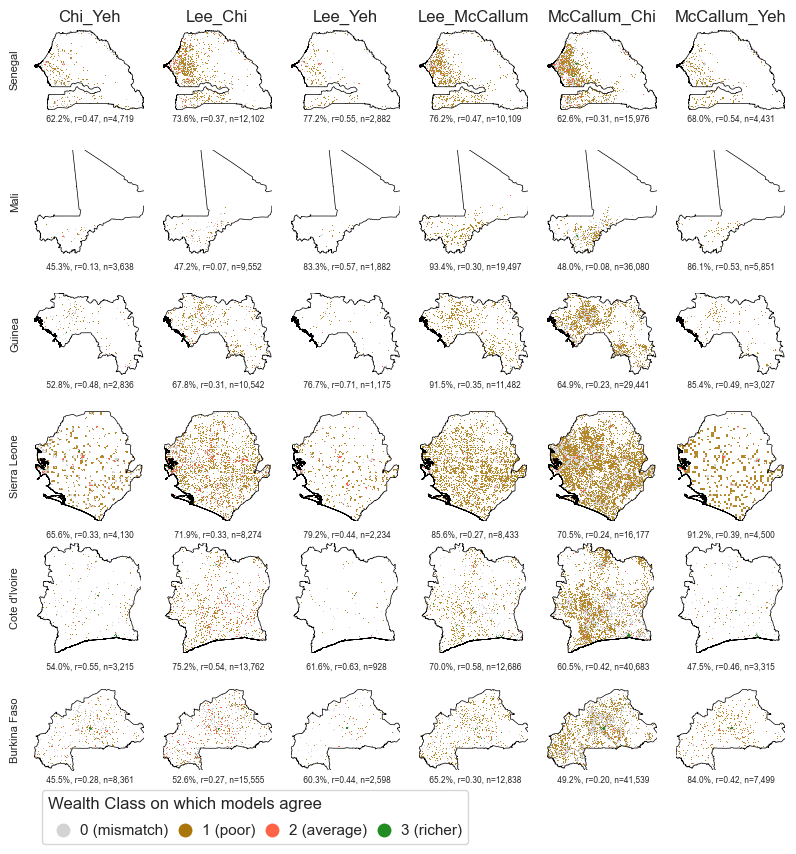

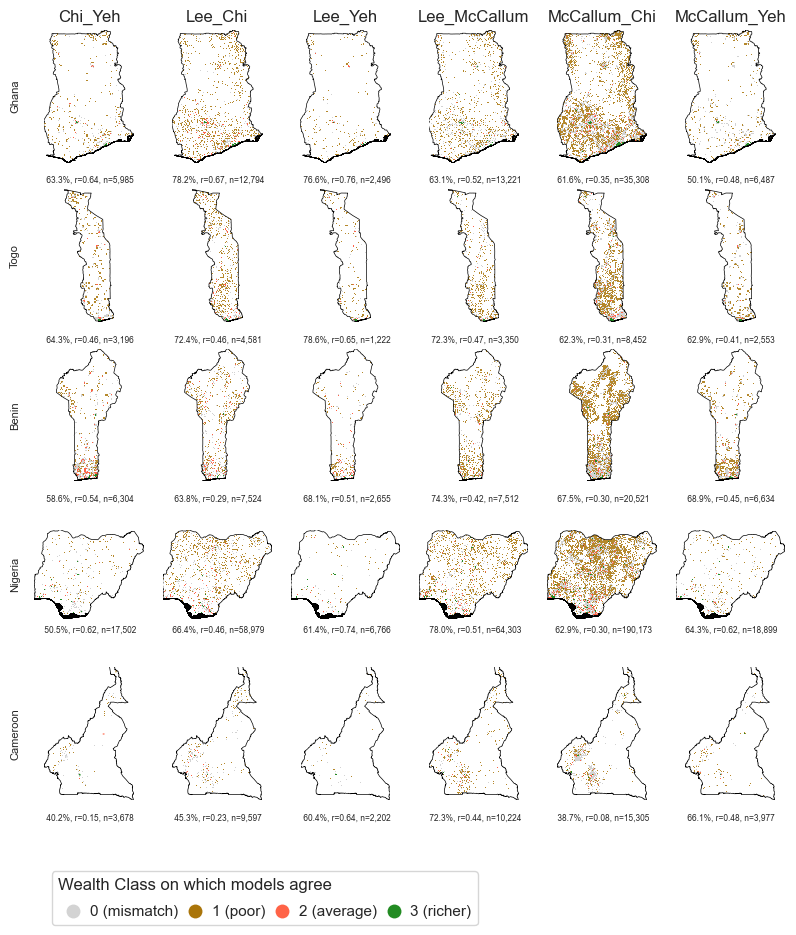

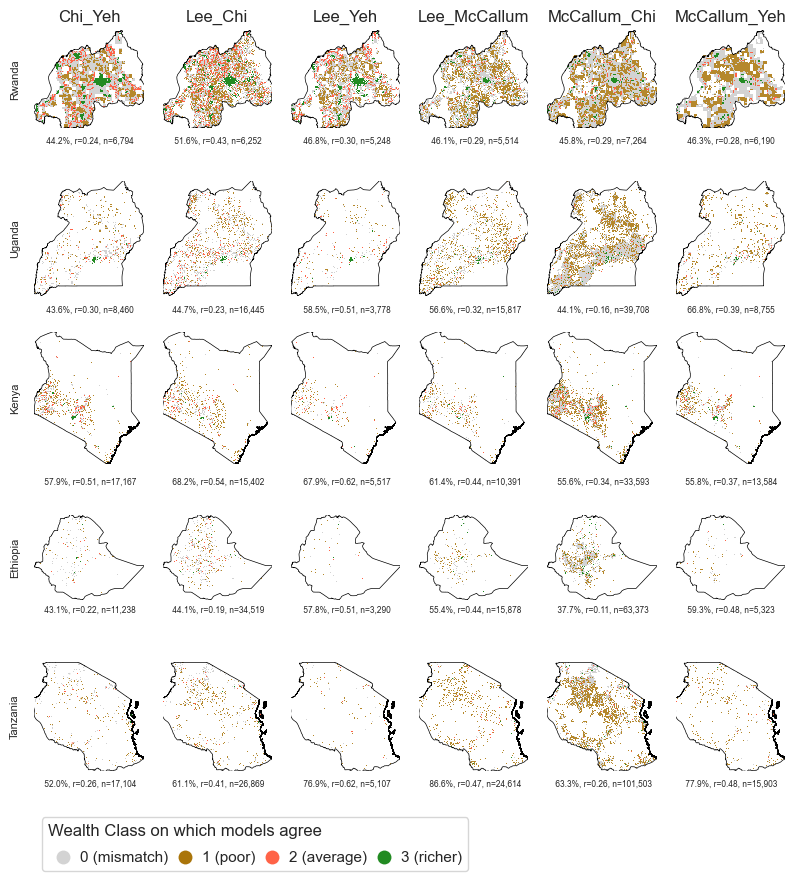

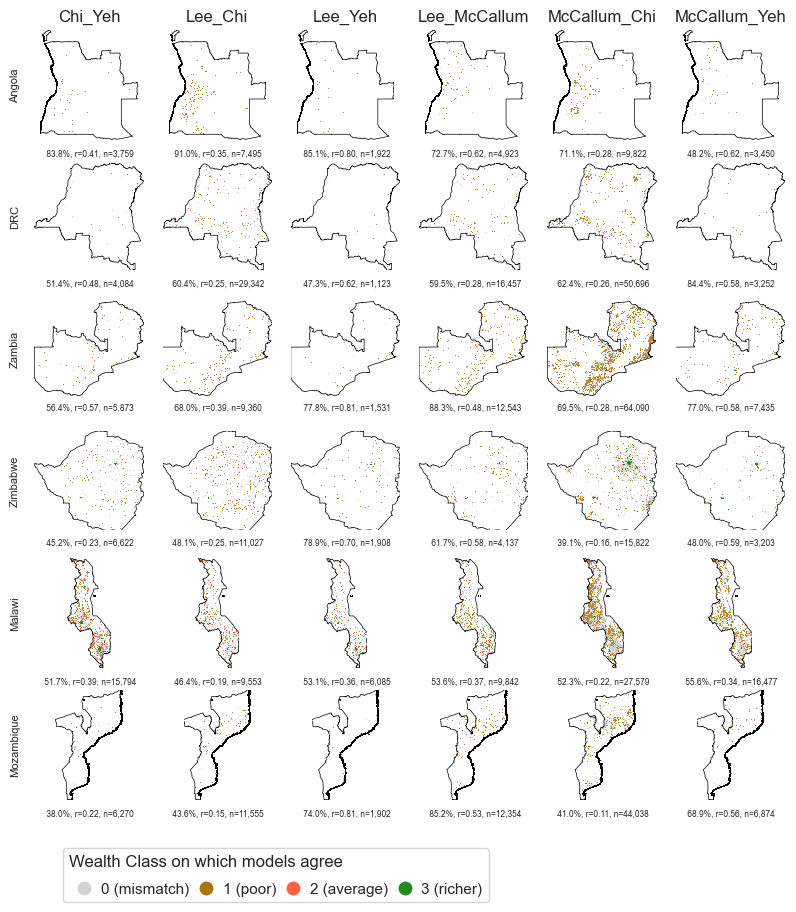

In [ ]:
wealth_classes = pd.read_csv(
    os.path.join(
        PROCESSED_DIR, "pixel-wise/terciles/unpooled", "Pairwise_wealth_classes.csv"
    )
)
# create a colormap for the wealth terciles
qmap = ListedColormap(
    ["lightgrey", "#aa750adc", "#ff6347", "#228B22"]
)  # mismatch, poor, average, richer

# template layer for plotting
template = gpd.read_file(PROCESSED_DIR / "ensemble_terciles.geojson")

for n, (tplt, grp) in enumerate(zip(["bfa", "cmr", "tza", "moz"], countries_ord)):
    # prepare the axes for plotting
    nrows = 6 if tplt in ["bfa", "moz"] else 5
    fig = plt.figure(constrained_layout=False, figsize=(10, 10))
    spec = fig.add_gridspec(ncols=7, nrows=nrows, width_ratios=[0.05, 1, 1, 1, 1, 1, 1])
    axs = np.empty((nrows, 7), dtype=object)
    for i in range(nrows):
        for j in range(7):
            axs[i, j] = fig.add_subplot(spec[i, j])

    grp_tplt = template[template["Country"] == tplt]

    for idy, cntry in enumerate(grp):
        # read the country boundary
        boundary = read_boundary(cntry)
        # filter agreement metrics for the country
        metrics = wealth_classes[wealth_classes["Country"] == cntry]

        for idx, pair in enumerate(MODEL_PAIRS, start=1):
            # read agreement map for current model pair
            da = rxr.open_rasterio(
                os.path.join(
                    INTERIM_DIR,
                    "raster_stacks",
                    "pairwise_agreement",
                    f"{pair}_{cntry}_models.tif",
                ),
                masked=True,
            ).squeeze()
            # plot map and boundary
            da.plot(ax=axs[idy, idx], cmap=qmap, add_colorbar=False)
            boundary.plot(
                ax=axs[idy, idx], facecolor="none", edgecolor="black", linewidth=0.5
            )

            # get metrics and plot annotations
            agree, coef, N = metrics.loc[
                metrics["Models"] == pair, ["agree", "correlation", "N"]
            ].T.to_numpy()
            axs[idy, idx].text(
                0.5,
                -0.15,
                f"{agree[0]: .1f}%, r={coef[0]:.2f}, n={N[0]:,.0f}",
                fontsize=6,
                ha="center",
                transform=axs[idy, idx].transAxes,
            )
            axs[idy, idx].set_title("")

        # label countries
        cntry = cntry if not cntry.endswith("Congo") else "DRC"
        axs[idy, 0].annotate(
            f"{cntry}",
            (0, 0.5),
            fontsize=8,
            va="center",
            transform=axs[idy, idx].transAxes,
            rotation=90,
        )
    # plot the template layer with wealth terciles
    grp_tplt.plot(
        ax=axs[nrows - 1, 1],
        column="Value",
        markersize=0.1,
        categorical=True,
        cmap=qmap,
        legend=True,
        categories=[0, 1, 2, 3],
        legend_kwds={
            "ncols": 4,
            "loc": "lower left",
            "labelspacing": 0.8,
            "frameon": True,
            "reverse": False,
            "alignment": "left",
            "title": "Wealth Class on which models agree",
            "bbox_to_anchor": (0, -1.0),
            "columnspacing": 0.1,
            "handletextpad": 0.1,
            "labels": ["0 (mismatch)", "1 (poor)", "2 (average)", "3 (richer)"],
        },
    )
    for ax in axs.flatten():
        ax.set_axis_off()
    for ax, pair in zip(axs[0, 1:], MODEL_PAIRS):
        ax.set_title(pair)

    plt.savefig(
        os.path.join(REPORTS_DIR, "figures", f"SI_fig5{page_nums[n]}.png"),
        dpi=300,
        bbox_inches="tight",
    )


### SI Figure 6: Pairwise wealth categories

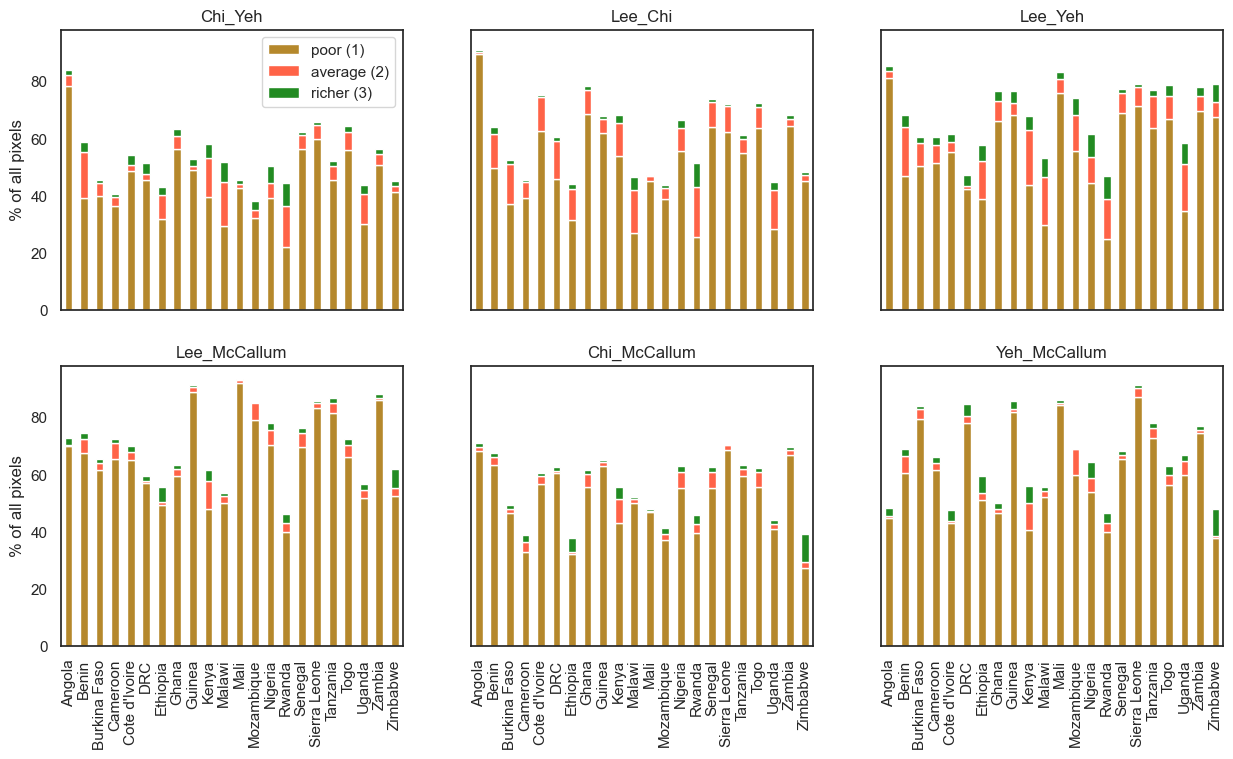

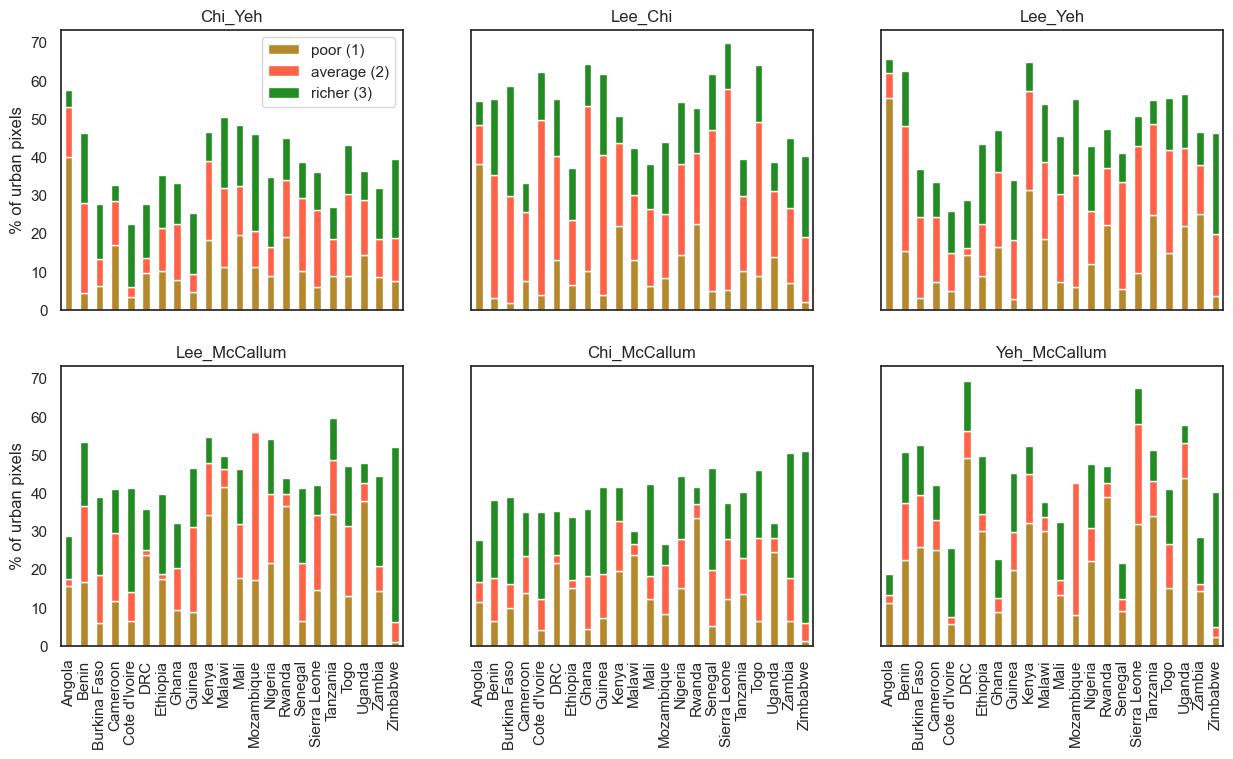

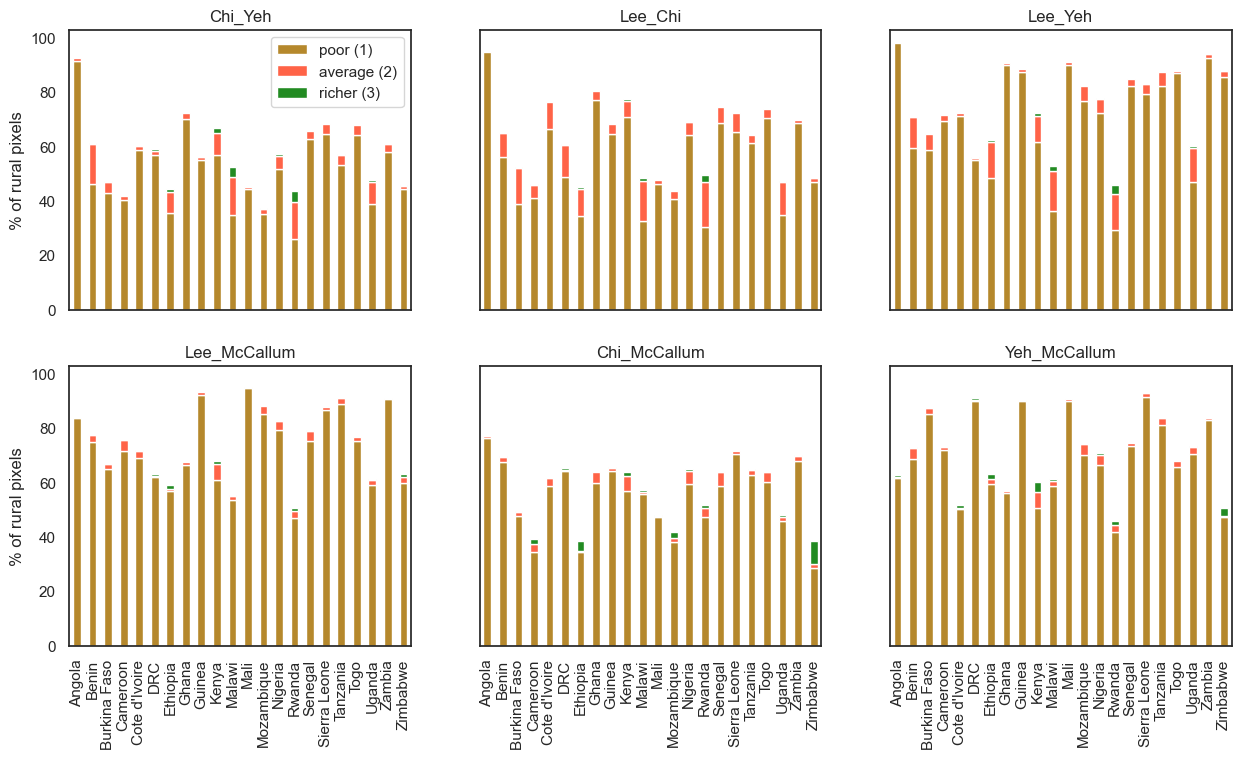

In [43]:
page_nums = {i: alpha for i, alpha in enumerate(["a", "b", "c"])}
model_pairs = np.array(MODEL_PAIRS).reshape(2, 3)

# read data
df = pd.read_csv(
    os.path.join(
        PROCESSED_DIR, "pixel-wise/terciles/unpooled", "Pairwise_wealth_classes.csv"
    )
).rename(columns={"model_pair": "Models"})
# filter for urban cluster
df["Country"] = df["Country"].replace({"Democratic Republic of the Congo": "DRC"})

for n, cl in zip(page_nums.keys(), ["all", "urban", "rural"]):
    wealth_classes = df[df["Cluster"] == cl][
        ["Country", "Models", "poor (1)", "average (2)", "richer (3)"]
    ].set_index("Country")

    fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex=True)
    # plot the data
    for i in range(2):
        for j in range(3):
            wealth_classes[wealth_classes["Models"] == model_pairs[i, j]].plot(
                kind="bar",
                stacked=True,
                ax=axs[i, j],
                color=["#aa750adc", "#ff6347", "#228B22"],
                legend=True,
            )
            axs[i, j].set_title(f"{model_pairs[i, j]}")
            axs[i, j].set_xlabel("")
            axs[i, j].set_ylabel(f"% of {cl} pixels")
    for ax in axs.flatten()[1:]:
        ax.legend().set_visible(False)
    plt.savefig(
        os.path.join(REPORTS_DIR, "figures", f"SI_fig6{page_nums[n]}.png"),
        dpi=300,
        bbox_inches="tight",
    )

### SI Figure 7: Correlation of models with DHS

In [8]:
# dictionary to hold aligned rasters for each country
rasters = dict()

for country in countries.keys():
    # align rasters to each other and resample to the same resolution
    rasters[country] = spatial_alignment(country)
# merge all countries into single raster
merged_raster = merge_arrays([rasters[country] for country in countries.keys()])

# load DHS rasters for each model
dhs = xr.concat(
    [
        rxr.open_rasterio(
            os.path.join(INTERIM_DIR, "rasterized", f"DHS_{model}.tif"), masked=True
        ).squeeze()
        for model in MODEL_NAMES
    ],
    dim="model",
).assign_coords(model=[model for model in MODEL_NAMES])

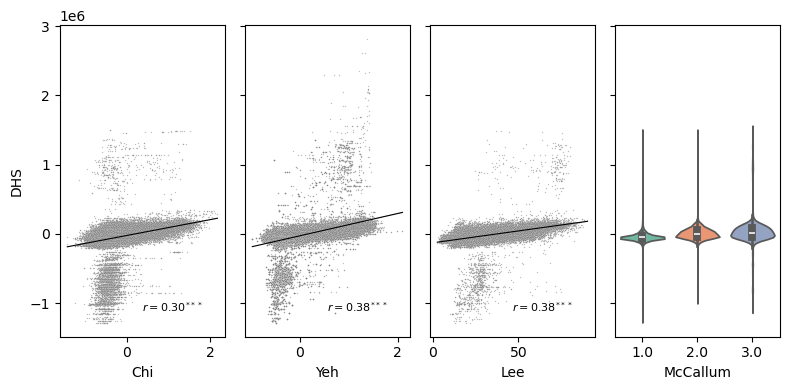

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(8, 4), tight_layout=True, sharey=True)

for model, ax in zip(["Chi", "Yeh", "Lee", "McCallum"], axs):
    ds = merged_raster.sel(model=model).to_dataset(name=model)
    ds["DHS"] = dhs.sel(model=model).rio.reproject_match(
        ds[model],
        resampling=Resampling.nearest if model == "McCallum" else Resampling.bilinear,
    )
    df = ds.to_dataframe().dropna().reset_index(drop=True)[[model, "DHS"]]

    if model == "McCallum":
        sns.violinplot(
            x=model,
            y="DHS",
            data=df,
            palette="Set2",
            inner="box",
            hue=model,
            ax=ax,
            legend=False,
        )
    else:
        coeff, p = pearsonr(df[model], df["DHS"])
        stars = "***" if p < 1e-5 else "*"

        sns.regplot(
            df,
            x=model,
            y="DHS",
            ax=ax,
            scatter=False,
            line_kws={"color": "black", "linewidth": 0.8},
        )
        sns.scatterplot(
            df,
            x=model,
            y="DHS",
            ax=ax,
            s=1,
            c="grey",
            alpha=0.5,
        )
        ax.text(
            0.5,
            0.08,
            f"$r = {coeff: .2f}^{{{stars}}}$",
            fontsize=8,
            transform=ax.transAxes,
        )
        if model != "Chi":
            ax.set_ylabel("")

plt.savefig(
    os.path.join(REPORTS_DIR, "figures", "SI_fig7.png"), dpi=300, bbox_inches="tight"
)

### SI Figure 8: Ensembles boxplots

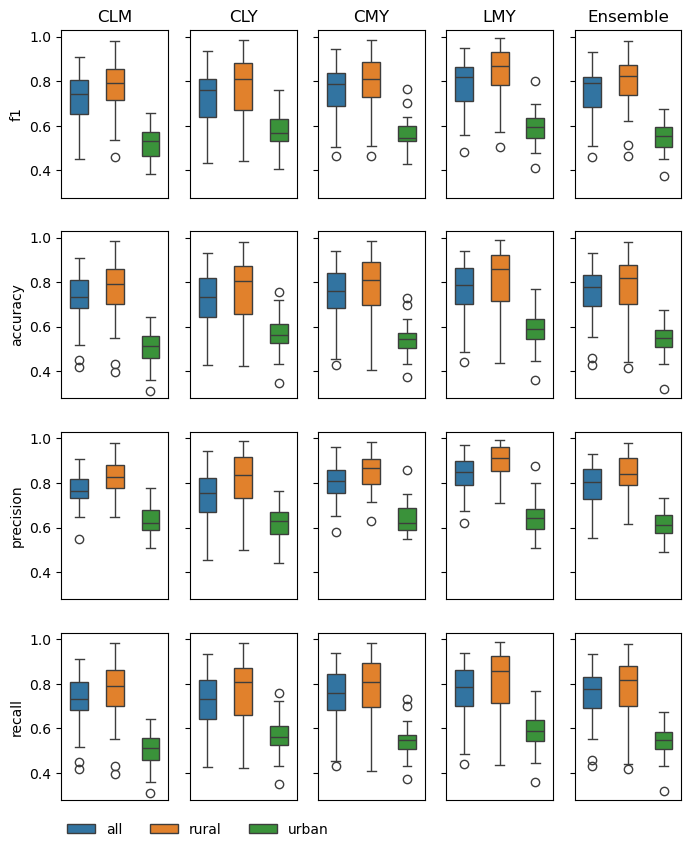

In [10]:
# read metrics for the different ensemble models
df = pd.read_csv(
    os.path.join(
        PROCESSED_DIR,
        "pixel-wise/terciles/unpooled",
        "Ensemble_metrics.csv",
    )
)
df = df.sort_values(by=["Cluster"])
ensembles = ["CLM", "CLY", "CMY", "LMY", "Ensemble"]

fig, axs = plt.subplots(4, len(ensembles), sharey=True, sharex=True, figsize=(8, 10))
for idy, metric in enumerate(["f1", "accuracy", "precision", "recall"]):
    for idx, model in enumerate(ensembles):
        sns.boxplot(
            df[df["metric"] == metric],
            x="Cluster",
            y=model,
            hue="Cluster",
            width=0.5,
            legend=True,
            ax=axs[idy, idx],
        )
        axs[0, idx].set_title(f"{model}")
    axs[idy, 0].set_ylabel(metric)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.legend().set_visible(False)
axs[3, 0].legend(loc=(0, -0.25), ncol=3, frameon=False).set_visible(True)

plt.savefig(
    os.path.join(REPORTS_DIR, "figures", "SI_fig8.png"), dpi=300, bbox_inches="tight"
)

### SI Figure 9: Original Models

In [11]:
rasters = dict()
# read rasterized model poverty maps
for model in MODEL_NAMES + ["DHS"]:
    rasters[model] = merge_arrays(
        [
            (rxr.open_rasterio(raster, masked=True).squeeze())
            for raster in glob(
                os.path.join(INTERIM_DIR, "rasterized", f"{model}_*.tif")
            )
            if os.path.basename(raster).split("_")[1][:-4] not in MODEL_NAMES
        ]
    )

# read majority vote ensemble poverty map
rasters["Ensemble"] = rxr.open_rasterio(
    os.path.join(
        PROCESSED_DIR,
        "pixel-wise/terciles/unpooled/majority",
        "majority_ensemble_map.tif",
    )
).squeeze()

# grids = dict()
# # create hexgrids of the rasters
# for name, raster in rasters.items():
#     grids[name] = raster_to_hexgrid(
#         raster,
#         agg_method="mode" if name in ["McCallum", "Ensemble"] else "mean",
#         factor=300,
#     )

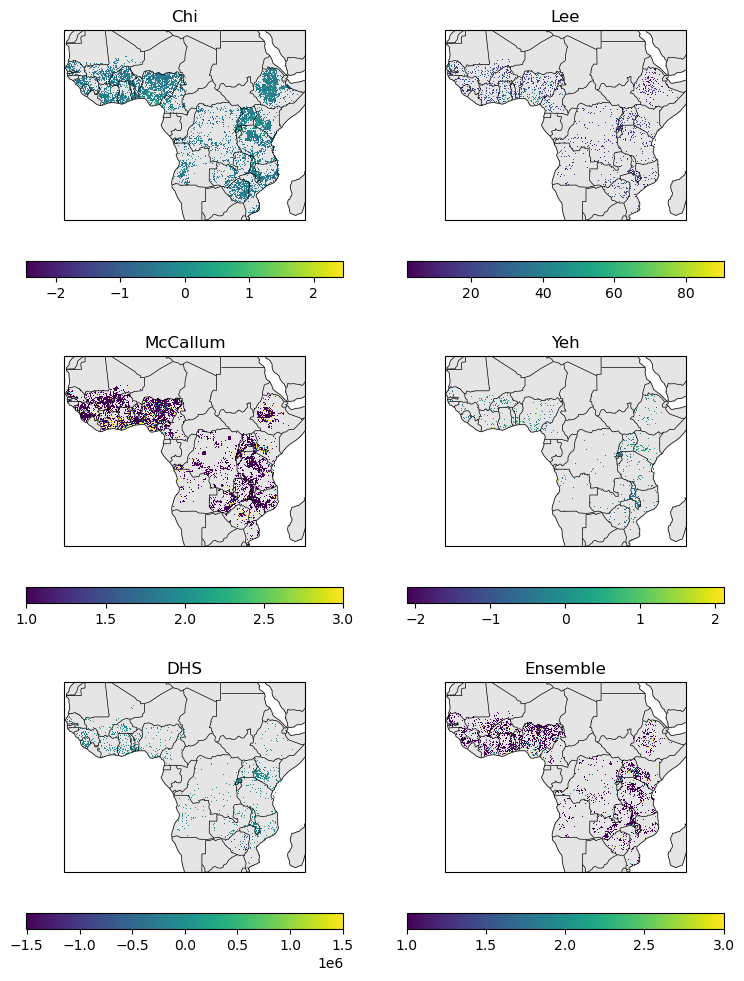

In [12]:
# colormaps = dict()
# for name in rasters.keys():
#     colormaps[name] = "viridis" if name in ["McCallum", "Ensemble"] else "YlOrBr_r"

fig, axs = plt.subplots(
    3,
    2,
    figsize=(9, 12),
    sharex=True,
    sharey=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
)
for name, ax in zip(rasters.keys(), axs.flatten()):
    # plot the raster
    rasters[name].plot.imshow(
        ax=ax,
        cmap="viridis",  # colormaps[name],
        add_colorbar=True,
        cbar_kwargs={"orientation": "horizontal"},
    )
    # # plot the choropleth
    # grids[name].plot(
    #     column="Value",
    #     ax=ax,
    #     cmap=colormaps[name],
    #     edgecolor="none",
    #     linewidth=0.01,
    #     legend=True,
    #     legend_kwds={
    #         "orientation": "horizontal",
    #     },
    #     missing_kwds={"color": "none", "label": "Nodata"},
    # )
    # add country boundaries and other features
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, color="grey", alpha=0.2)
    # # add tickmarks
    # ax.set_xticks([-15, 15, 45], crs=ccrs.PlateCarree())
    # ax.set_yticks([-20, 0, 20], crs=ccrs.PlateCarree())
    # ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    # ax.yaxis.set_major_formatter(LatitudeFormatter())

    ax.set_title(f"{name}")

# for ax in axs.flatten():
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.set_axis_off()
plt.savefig(
    os.path.join(REPORTS_DIR, "figures", "SI_fig9.png"), dpi=300, bbox_inches="tight"
)

In [6]:
# # read pairwise agreement proportions
# correlation = pd.read_csv(
#     os.path.join(
#         PROCESSED_DIR,
#         "pixel-wise/terciles/unpooled",
#         "Pairwise_correlation.csv",
#     )
# )
# correlation["Country"] = correlation["Country"].replace(
#     {"Democratic Republic of the Congo": "DRC"}
# )
# correlation = (correlation[correlation["Cluster"] == "all"].set_index("Country"))[
#     MODEL_PAIRS
# ]
# # plot the data
# fig, axs = plt.subplots(1, 1, figsize=(8, 8))
# sns.heatmap(
#     correlation,
#     annot=True,
#     fmt=".2f",
#     cmap="YlGnBu",
#     cbar_kws={"label": "Spearman's Rho coefficient"},
# )
# axs.set_ylabel("")
# # plt.savefig(
# #     os.path.join(REPORTS_DIR, "figures", "SI_fig2.png"), dpi=300, bbox_inches="tight"
# # )

### Model agreement by population

In [22]:
# read spatial agreement map
ds = (
    rxr.open_rasterio(
        os.path.join(
            PROCESSED_DIR,
            "pixel-wise/terciles/unpooled/majority",
            "spatial_agreement_map.tif",
        ),
        masked=True,
    )
    .squeeze()
    .to_dataset(name="agreement")
)

# merge population density rasters for countries into single raster
popn = merge_arrays(
    [
        rxr.open_rasterio(
            f"../data/external/population/{country.lower()}_ppp_2020_1km_Aggregated.tif",
            masked=True,
        ).squeeze()
        for country in countries.values()
    ]
)
# align population raster to agreement map
ds["popn"] = popn.rio.reproject_match(
    ds["agreement"], resampling=Resampling.bilinear
).where(ds["agreement"].notnull())
# read urbanisation raster
ds["smod"] = (
    rxr.open_rasterio(r"../data/external/SMOD_Africa.tif", masked=True)
    .squeeze()
    .rio.reproject_match(ds["agreement"], resampling=Resampling.nearest)
    .where(ds["agreement"].notnull())
)
# export values to dataframe
df = ds.to_dataframe().dropna().reset_index(drop=True)[["agreement", "popn", "smod"]]

In [28]:
stats = pd.DataFrame()
# summarise population by model agreement (or poverty class) and urbanisation
for i, cls in enumerate([None, "rural", "urban"]):
    data = df[df["smod"] == i] if cls else df.copy()
    summary = data["popn"].groupby(by=[data["agreement"]]).sum().reset_index()
    summary["urban_class"] = cls if cls else "all"
    stats = pd.concat([stats, summary], ignore_index=True)
# calculate percentage population (within each urban_class)
stats["pct_popn"] = (
    stats["popn"] / stats.groupby("urban_class")["popn"].transform("sum")
) * 100

stats


,agreement,popn,urban_class,pct_popn
0,0.0,5.570232e+07,all,25.435511
1,1.0,8.304024e+06,all,3.791890
2,2.0,9.650421e+07,all,44.066990
3,3.0,4.255410e+07,all,19.431601
4,4.0,1.592967e+07,all,7.274009
5,0.0,3.725402e+07,rural,32.628708
6,1.0,1.326224e+06,rural,1.161565
7,2.0,5.903280e+07,rural,51.703526
8,3.0,1.521446e+07,rural,13.325492
9,4.0,1.348080e+06,rural,1.180708


### Model agreement and development Indicators

In [3]:
# import pandas as pd
# import requests

# # Fetch the data.
# df = pd.read_csv(
#     "https://ourworldindata.org/grapher/share-of-population-in-extreme-poverty.csv?v=1&csvType=full&useColumnShortNames=true",
#     storage_options={"User-Agent": "Our World In Data data fetch/1.0"},
# )

# # Fetch the metadata
# metadata = requests.get(
#     "https://ourworldindata.org/grapher/share-of-population-in-extreme-poverty.metadata.json?v=1&csvType=full&useColumnShortNames=true"
# ).json()
# # Print the first few rows of the dataframe
# df.head()

In [4]:
# data = (
#     df[df["Code"].isin(countries.values()) & (df["Year"] >= 2015)]
#     .rename(
#         columns={
#             "Entity": "Country",
#             "headcount_ratio__ppp_version_2021__poverty_line_300__welfare_type_income_or_consumption__table_income_or_consumption_consolidated__survey_comparability_no_spells": "poverty_rate",
#         }
#     )
#     .dropna(subset=["poverty_rate"])
#     .sort_values(by=["Country", "Year"])
#     .groupby("Country")[["Code", "Year", "poverty_rate"]]
#     .agg("first")
#     .reset_index()
# )
# data

In [5]:
# fig, axs = plt.subplots(1, 1, figsize=(10, 6))
# sns.barplot(
#     ax=axs,
#     data=data,
#     x="Code",
#     y="poverty_rate",
#     hue="poverty_rate",
#     palette="OrRd",
#     dodge=False,
#     legend=False,
# )
# axs.set_ylabel("Poverty headcount ratio (%)")
# axs.set_xlabel("")
# axs.set_xticklabels(axs.get_xticklabels(), rotation=45)
# plt.tight_layout()

In [32]:
ensemble_stats = pd.read_csv(
    os.path.join(
        PROCESSED_DIR,
        "pixel-wise/quintiles/unpooled/unanimous",
        "agreement_pixel_stats.csv",
    )
).replace({"Democratic Republic of the Congo": "DRC"})
ensemble_stats = ensemble_stats[ensemble_stats["Cluster"] == "all"]
ensemble_stats[">=2 models agree"] = (
    ensemble_stats[["2 models agree", "3 models agree"]].sum(axis=1).round(2)
)
ensemble_stats

,Country,Cluster,No agreement,2 models agree,3 models agree,>=2 models agree
1,Angola,all,22.1,39.8,38.0,77.8
5,Benin,all,34.4,44.2,21.4,65.6
6,Burkina Faso,all,33.6,46.7,19.7,66.4
9,Cameroon,all,28.9,55.1,16.0,71.1
14,Cote d'Ivoire,all,25.2,51.3,23.5,74.8
15,DRC,all,29.4,45.6,25.0,70.6
18,Ethiopia,all,33.6,50.2,16.3,66.5
22,Ghana,all,20.2,50.1,29.7,79.8
24,Guinea,all,28.7,41.8,29.6,71.4
27,Kenya,all,28.7,49.7,21.6,71.3


In [7]:
# stats = pd.merge(
#     data[["Country", "poverty_rate"]],
#     ensemble_stats.drop(columns=["Cluster"]),
#     on="Country",
#     how="left",
# )
# stats.loc[stats["Country"].str.endswith("Congo"), stats.columns[2:]] = (
#     ensemble_stats.loc[
#         ensemble_stats["Country"].str.endswith("Congo"), ensemble_stats.columns[2:]
#     ].values
# )  # fix DRC missing
# stats

In [8]:
indicators = pd.read_csv(
    r"../data/external/World_Development_Indicators/Indicators.csv"
)
forest = indicators.loc[:22, ["Country Code", "2022 [YR2022]"]]
popn = indicators.loc[23:, ["Country Code", "2022 [YR2022]"]]
indicators = pd.merge(
    forest.rename(columns={"2022 [YR2022]": "forest_area"}),
    popn.rename(columns={"2022 [YR2022]": "pop_density"}),
    on="Country Code",
    how="inner",
)
country_names = {v: k for k, v in countries.items()}
indicators["Country"] = indicators["Country Code"].map(
    lambda x: country_names.get(x, x)
)
indicators = indicators[["Country", "forest_area", "pop_density"]]
indicators

,Country,forest_area,pop_density
0,SSA,26.457537,48.489261
1,Angola,52.536497,28.583484
2,Benin,26.916903,122.024663
3,Burkina Faso,22.355263,82.269876
4,Cameroon,42.792579,58.456075
5,Democratic Republic of the Congo,54.675459,45.167494
6,Cote d'Ivoire,8.210500,95.581767
7,Ethiopia,14.995585,111.107151
8,Ghana,35.160443,145.689425
9,Guinea,24.861631,57.199809


In [9]:
stats = pd.merge(
    indicators,
    ensemble_stats.drop(columns=["Cluster"]),
    on="Country",
    how="left",
)
stats

,Country,forest_area,pop_density,No agreement,Split agreement,2 models agree,3 models agree,All models agree
0,SSA,26.457537,48.489261,NaN,NaN,NaN,NaN,NaN
1,Angola,52.536497,28.583484,13.3,0.4,74.6,10.9,0.7
2,Benin,26.916903,122.024663,15.2,1.8,57.8,22.0,3.2
3,Burkina Faso,22.355263,82.269876,31.7,0.9,54.6,11.9,0.9
4,Cameroon,42.792579,58.456075,36.2,0.5,54.8,8.0,0.5
5,Democratic Republic of the Congo,54.675459,45.167494,29.2,0.2,62.7,7.7,0.2
6,Cote d'Ivoire,8.210500,95.581767,27.8,0.1,56.8,14.8,0.5
7,Ethiopia,14.995585,111.107151,48.0,0.3,46.5,4.9,0.3
8,Ghana,35.160443,145.689425,23.2,0.7,56.2,18.3,1.6
9,Guinea,24.861631,57.199809,20.7,0.3,60.7,17.2,1.1


In [10]:
@interact
def plot_vars(
    ensemble_var=ensemble_stats.columns[2:].to_list(),
    indicator=indicators.columns[1:].to_list(),
):
    fig, axs = plt.subplots(1, 1, figsize=(5, 5))
    sns.regplot(
        stats,
        x=indicator,
        y=ensemble_var,
        ax=axs,
        scatter=False,
        line_kws={"color": "black"},
    )
    sns.scatterplot(
        stats,
        x=indicator,
        y=ensemble_var,
        ax=axs,
    )
    # plt.show()
    return

interactive(children=(Dropdown(description='ensemble_var', options=('No agreement', 'Split agreement', '2 mode…

In [33]:
gini = (
    pd.read_csv(
        r"../data/external/World_Development_Indicators/economic-inequality-gini-index.csv"
    )
    .rename(
        columns={"Entity": "Country", "Gini coefficient (2021 prices)": "gini_index"}
    )
    .drop("World region according to OWID", axis=1)
    .replace({"Democratic Republic of Congo": "DRC"})
)
# filter for African countries and recent years
gini = (
    gini[gini["Code"].isin(countries.values()) & (gini["Year"] >= 2015)]
    .sort_values(by=["Country", "Year"])
    .dropna(subset=["gini_index"])
    .groupby("Country")
    .agg("last")
    .reset_index()
)
gini

,Country,Code,Year,gini_index
0,Angola,AGO,2018,0.512643
1,Benin,BEN,2021,0.343958
2,Burkina Faso,BFA,2021,0.373913
3,Cameroon,CMR,2021,0.421761
4,Cote d'Ivoire,CIV,2021,0.352754
5,DRC,COD,2020,0.446732
6,Ethiopia,ETH,2021,0.311418
7,Ghana,GHA,2016,0.435086
8,Guinea,GIN,2018,0.295920
9,Kenya,KEN,2022,0.377438


In [34]:
data = pd.merge(
    gini[["Country", "gini_index"]],
    ensemble_stats.drop(columns=["Cluster"]),
    on="Country",
    how="left",
)
data

,Country,gini_index,No agreement,2 models agree,3 models agree,>=2 models agree
0,Angola,0.512643,22.1,39.8,38.0,77.8
1,Benin,0.343958,34.4,44.2,21.4,65.6
2,Burkina Faso,0.373913,33.6,46.7,19.7,66.4
3,Cameroon,0.421761,28.9,55.1,16.0,71.1
4,Cote d'Ivoire,0.352754,25.2,51.3,23.5,74.8
5,DRC,0.446732,29.4,45.6,25.0,70.6
6,Ethiopia,0.311418,33.6,50.2,16.3,66.5
7,Ghana,0.435086,20.2,50.1,29.7,79.8
8,Guinea,0.295920,28.7,41.8,29.6,71.4
9,Kenya,0.377438,28.7,49.7,21.6,71.3


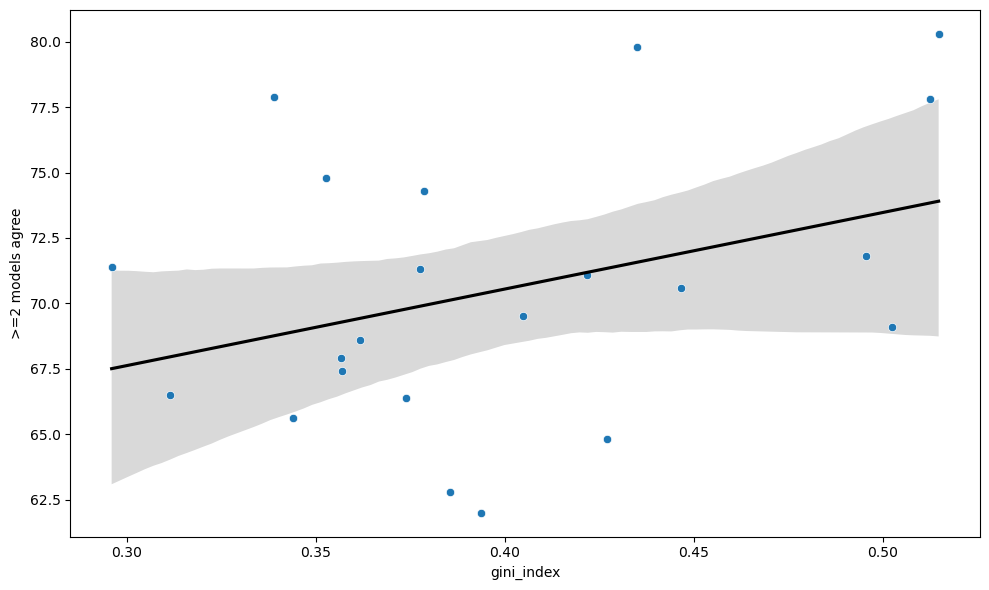

In [35]:
fig, axs = plt.subplots(1, 1, figsize=(10, 6))
sns.regplot(
    data,
    x="gini_index",
    y=">=2 models agree",
    ax=axs,
    scatter=False,
    line_kws={"color": "black"},
)
sns.scatterplot(
    data,
    x="gini_index",
    y=">=2 models agree",
    ax=axs,
)
# axs.set_ylabel("Poverty headcount ratio (%)")
# axs.set_xlabel("")
# axs.set_xticklabels(axs.get_xticklabels(), rotation=45)
plt.tight_layout()

In [41]:
gdf = gpd.read_file(
    PROCESSED_DIR / "admin-2/quintiles/unpooled/majority/admin_ensembles.geojson"
)
gdf

,GID_2,country_name,NAME_2,Chi_index,Lee_index,Yeh_index,models,Chi,Lee,Yeh,majority,agreement,geometry
0,AGO.1.1_1,Angola,Ambriz,-0.407343,36.907653,0.612656,3,2.0,4.0,4.0,4.0,2.0,"MULTIPOLYGON (((13.29653 -8.22625, 13.29653 -8..."
1,AGO.1.2_1,Angola,Dande,-0.166423,52.903250,0.791476,3,5.0,5.0,5.0,5.0,3.0,"MULTIPOLYGON (((14.28350 -8.85015, 14.29735 -8..."
2,AGO.1.3_1,Angola,Icolo e Bengo,-0.097248,39.109634,0.566751,3,5.0,4.0,4.0,4.0,2.0,"MULTIPOLYGON (((14.19018 -9.24194, 14.17060 -9..."
3,AGO.1.4_1,Angola,Muxima,-0.174021,37.967159,0.729507,3,5.0,4.0,5.0,5.0,2.0,"MULTIPOLYGON (((14.19127 -10.28695, 14.20111 -..."
4,AGO.1.5_1,Angola,Nambuangongo,-0.336152,20.570845,-0.463021,3,4.0,3.0,1.0,NaN,0.0,"MULTIPOLYGON (((14.41048 -8.38555, 14.41245 -8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2962,ZWE.10.4_1,Zimbabwe,Gweru,-0.363722,66.325630,0.781064,3,4.0,5.0,5.0,5.0,2.0,"MULTIPOLYGON (((30.18523 -19.48782, 30.18533 -..."
2963,ZWE.10.5_1,Zimbabwe,Kwekwe,-0.459579,61.852514,0.782603,3,2.0,5.0,5.0,5.0,2.0,"MULTIPOLYGON (((29.12566 -19.32328, 29.12711 -..."
2964,ZWE.10.6_1,Zimbabwe,Mberengwa,-0.473668,28.331405,-0.475157,3,2.0,2.0,1.0,2.0,2.0,"MULTIPOLYGON (((29.47790 -21.02500, 29.49099 -..."
2965,ZWE.10.7_1,Zimbabwe,Shurugwi,-0.437417,43.399042,0.427483,3,3.0,4.0,4.0,4.0,2.0,"MULTIPOLYGON (((30.14902 -20.02647, 30.14950 -..."


In [42]:
gdf[gdf[["Chi", "Lee", "Yeh"]].isnull().any(axis=1)]

,GID_2,country_name,NAME_2,Chi_index,Lee_index,Yeh_index,models,Chi,Lee,Yeh,majority,agreement,geometry
32,AGO.5.6_1,Angola,Mavinga,-0.445670,23.244700,NaN,2,1.0,3.0,NaN,NaN,0.0,"MULTIPOLYGON (((20.47288 -17.01626, 20.47603 -..."
34,AGO.5.8_1,Angola,Nancova,-0.153928,27.310704,NaN,2,5.0,4.0,NaN,NaN,0.0,"MULTIPOLYGON (((18.85405 -16.95947, 18.87484 -..."
118,AGO.14.6_1,Angola,Cuaba Nzogo,-0.388023,19.231528,NaN,2,2.0,3.0,NaN,NaN,0.0,"MULTIPOLYGON (((16.43504 -9.30943, 16.44617 -9..."
126,AGO.14.14_1,Angola,Quirima,-0.412834,10.765329,NaN,2,2.0,1.0,NaN,NaN,0.0,"MULTIPOLYGON (((18.34180 -10.66927, 18.33262 -..."
132,AGO.15.6_1,Angola,Lucano,-0.466979,10.357131,NaN,2,1.0,1.0,NaN,1.0,2.0,"MULTIPOLYGON (((22.48736 -11.13187, 22.48716 -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2596,TZA.21.2_1,Tanzania,Lake Rukwa,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((32.11530 -8.18360, 32.11539 -8..."
2615,TZA.24.4_1,Tanzania,Lake Eyasi,-0.690000,14.796744,NaN,2,1.0,1.0,NaN,1.0,2.0,"MULTIPOLYGON (((34.78795 -3.79671, 34.78834 -3..."
2713,UGA.15.1_1,Uganda,Bujumba,-0.212654,32.556509,NaN,2,3.0,5.0,NaN,NaN,0.0,"MULTIPOLYGON (((32.19292 -0.50653, 32.19292 -0..."
2782,UGA.40.3_1,Uganda,Moroto,NaN,45.615533,-0.456516,2,NaN,5.0,3.0,NaN,0.0,"MULTIPOLYGON (((34.66927 2.52114, 34.66839 2.5..."


In [43]:
gdf[gdf["agreement"].notnull()]

,GID_2,country_name,NAME_2,Chi_index,Lee_index,Yeh_index,models,Chi,Lee,Yeh,majority,agreement,geometry
0,AGO.1.1_1,Angola,Ambriz,-0.407343,36.907653,0.612656,3,2.0,4.0,4.0,4.0,2.0,"MULTIPOLYGON (((13.29653 -8.22625, 13.29653 -8..."
1,AGO.1.2_1,Angola,Dande,-0.166423,52.903250,0.791476,3,5.0,5.0,5.0,5.0,3.0,"MULTIPOLYGON (((14.28350 -8.85015, 14.29735 -8..."
2,AGO.1.3_1,Angola,Icolo e Bengo,-0.097248,39.109634,0.566751,3,5.0,4.0,4.0,4.0,2.0,"MULTIPOLYGON (((14.19018 -9.24194, 14.17060 -9..."
3,AGO.1.4_1,Angola,Muxima,-0.174021,37.967159,0.729507,3,5.0,4.0,5.0,5.0,2.0,"MULTIPOLYGON (((14.19127 -10.28695, 14.20111 -..."
4,AGO.1.5_1,Angola,Nambuangongo,-0.336152,20.570845,-0.463021,3,4.0,3.0,1.0,NaN,0.0,"MULTIPOLYGON (((14.41048 -8.38555, 14.41245 -8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2962,ZWE.10.4_1,Zimbabwe,Gweru,-0.363722,66.325630,0.781064,3,4.0,5.0,5.0,5.0,2.0,"MULTIPOLYGON (((30.18523 -19.48782, 30.18533 -..."
2963,ZWE.10.5_1,Zimbabwe,Kwekwe,-0.459579,61.852514,0.782603,3,2.0,5.0,5.0,5.0,2.0,"MULTIPOLYGON (((29.12566 -19.32328, 29.12711 -..."
2964,ZWE.10.6_1,Zimbabwe,Mberengwa,-0.473668,28.331405,-0.475157,3,2.0,2.0,1.0,2.0,2.0,"MULTIPOLYGON (((29.47790 -21.02500, 29.49099 -..."
2965,ZWE.10.7_1,Zimbabwe,Shurugwi,-0.437417,43.399042,0.427483,3,3.0,4.0,4.0,4.0,2.0,"MULTIPOLYGON (((30.14902 -20.02647, 30.14950 -..."
